## PART A

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load Data both csv file 

In [2]:
#market sentiment
df1 = pd.read_csv("fear_greed_index.csv")

#trader sentiment
df2 = pd.read_csv("historical_data.csv")

In [3]:
df1

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05
...,...,...,...,...
2639,1745818200,54,Neutral,2025-04-28
2640,1745904600,60,Greed,2025-04-29
2641,1745991000,56,Greed,2025-04-30
2642,1746077400,53,Neutral,2025-05-01


In [4]:
df2

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,25-04-2025 15:35,7546.600000,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,25-04-2025 15:35,7164.400000,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,25-04-2025 15:35,5040.300000,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,25-04-2025 15:35,4616.900000,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12


### Basic info

In [5]:
df1.shape

(2644, 4)

In [6]:
df2.shape

(211224, 16)

### Missing Value

In [7]:
df1.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [8]:
df2.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

### Duplicate Rows

In [9]:
df1.duplicated().sum()

np.int64(0)

In [10]:
df2.duplicated().sum()

np.int64(0)

### Date/Timestamp

#### Sentiment Dataset

In [11]:
df1.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='str')

In [12]:
df1['date'] = pd.to_datetime(df1['date'])

#### Trader Dataset

In [13]:
df2.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='str')

In [14]:
df2['Timestamp IST'] = pd.to_datetime(
    df2['Timestamp IST'], 
    format='%d-%m-%Y %H:%M'
)

#### Merge Dataset

In [15]:
df1.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='str')

In [16]:
# clean column names
df1.columns = df1.columns.str.lower().str.strip().str.replace(' ', '_')
df2.columns = df2.columns.str.lower().str.strip().str.replace(' ', '_')

In [17]:
# df1 (sentiment)
df1['date'] = pd.to_datetime(df1['date'])

# df2 (trader)
df2['timestamp_ist'] = pd.to_datetime(df2['timestamp_ist'], format='%d-%m-%Y %H:%M')
df2['date'] = df2['timestamp_ist'].dt.floor('D')

In [18]:
merged_df = pd.merge(df2, df1, on='date', how='left')

In [19]:
merged_df.head()

,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp_x,date,timestamp_y,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed


### Daily PnL per account

In [20]:
daily_pnl = merged_df.groupby(['account', 'date'])['closed_pnl'].sum().reset_index()

In [21]:
daily_pnl

,account,date,closed_pnl
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.000000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.100000
...,...,...,...
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,1709.194807
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,4008.588908
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,8561.771838
2339,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,2520.773814


In [22]:
daily_pnl.head()

,account,date,closed_pnl
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1


### Number of trades per day

In [23]:
trades_per_day = merged_df.groupby('date').size().reset_index(name='num_trades')

In [24]:
trades_per_day.head()

,date,num_trades
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3


### Average trade size

In [25]:
avg_trade_size = merged_df.groupby('account')['size_usd'].mean().reset_index()

In [26]:
avg_trade_size.head()

,account,size_usd
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


### Win rate profit

In [27]:
merged_df['win'] = merged_df['closed_pnl'] > 0

win_rate = merged_df.groupby('account')['win'].mean().reset_index()

### Long/Short ratio

In [28]:
long_short = merged_df.groupby(['date', 'side']).size().unstack().fillna(0)

In [29]:
long_short

side,BUY,SELL
date,,
2023-05-01,3.0,0.0
2023-12-05,7.0,2.0
2023-12-14,5.0,6.0
2023-12-15,2.0,0.0
2023-12-16,3.0,0.0
...,...,...
2025-04-27,209.0,128.0
2025-04-28,652.0,727.0
2025-04-29,1105.0,1138.0


### Leverage distribution

In [30]:
print(merged_df.columns)

Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp_x', 'date', 'timestamp_y', 'value', 'classification', 'win'],
      dtype='str')


In [31]:
if 'leverage' in merged_df.columns:
    print(merged_df['leverage'].describe())
else:
    print("Leverage column not found in dataset")

Leverage column not found in dataset


In [32]:
print(merged_df.columns)

Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp_x', 'date', 'timestamp_y', 'value', 'classification', 'win'],
      dtype='str')


In [33]:
merged_df['size_usd'].describe()

count    2.112240e+05
mean     5.639451e+03
std      3.657514e+04
min      0.000000e+00
25%      1.937900e+02
50%      5.970450e+02
75%      2.058960e+03
max      3.921431e+06
Name: size_usd, dtype: float64

In [34]:
merged_df['closed_pnl'].describe()

count    211224.000000
mean         48.749001
std         919.164828
min     -117990.104100
25%           0.000000
50%           0.000000
75%           5.792797
max      135329.090100
Name: closed_pnl, dtype: float64

In [35]:
merged_df.groupby('date').size()

date
2023-05-01       3
2023-12-05       9
2023-12-14      11
2023-12-15       2
2023-12-16       3
              ... 
2025-04-27     337
2025-04-28    1379
2025-04-29    2243
2025-04-30    1113
2025-05-01    1230
Length: 480, dtype: int64

In [36]:
merged_df['side'].value_counts()

side
SELL    108528
BUY     102696
Name: count, dtype: int64

## Calculate median 

In [37]:
median_value = merged_df['size_usd'].median()

merged_df['risk_level'] = merged_df['size_usd'].apply(
    lambda x: 'High' if x > median_value else 'Low'
)

In [38]:
round(median_value, 2)

np.float64(597.05)

In [39]:
median_value

np.float64(597.0450000000001)

In [40]:
median_value = merged_df['size_usd'].median()

merged_df['risk_level'] = merged_df['size_usd'].apply(
    lambda x: 'High' if x > median_value else 'Low'
)

In [41]:
import numpy as np

median_value = merged_df['size_usd'].median()

merged_df['risk_level'] = np.where(
    merged_df['size_usd'] > median_value,
    'High',
    'Low'
)

In [42]:
median_value = merged_df['size_usd'].median()

merged_df['risk_level'] = (
    merged_df['size_usd'] > median_value
).map({True: 'High', False: 'Low'})

In [43]:
import numpy as np

median_value = merged_df['size_usd'].median()
merged_df['risk_level'] = np.where(merged_df['size_usd'] > median_value, 'High', 'Low')

## PART B

### Average PnL by Sentiment

In [44]:
pnl_by_sentiment = merged_df.groupby('classification')['closed_pnl'].mean().reset_index()
pnl_by_sentiment

,classification,closed_pnl
0,Extreme Fear,34.537862
1,Extreme Greed,67.892861
2,Fear,54.290400
3,Greed,42.743559
4,Neutral,34.307718


### Win Rate by Sentiment

In [45]:
winrate_by_sentiment = merged_df.groupby('classification')['win'].mean().reset_index()
print(winrate_by_sentiment)

  classification       win
0   Extreme Fear  0.370607
1  Extreme Greed  0.464943
2           Fear  0.420768
3          Greed  0.384828
4        Neutral  0.396991


### CHART

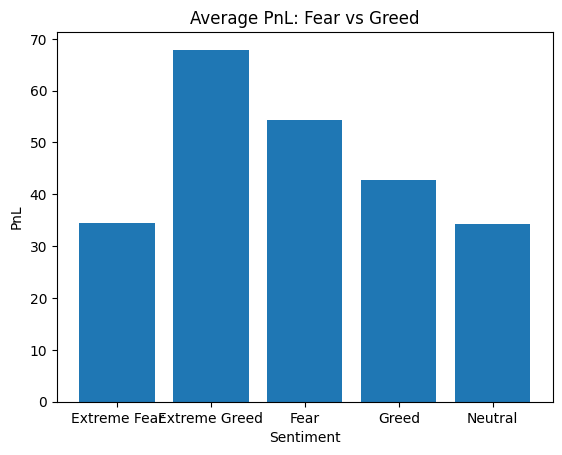

In [46]:
import matplotlib.pyplot as plt

plt.bar(pnl_by_sentiment['classification'], pnl_by_sentiment['closed_pnl'])
plt.title("Average PnL: Fear vs Greed")
plt.xlabel("Sentiment")
plt.ylabel("PnL")
plt.show()

### Trade Frequency

In [47]:
trades_count = merged_df.groupby(['date', 'classification']).size().reset_index(name='num_trades')

trades_summary = trades_count.groupby('classification')['num_trades'].mean().reset_index()
print(trades_summary)

  classification   num_trades
0   Extreme Fear  1528.571429
1  Extreme Greed   350.807018
2           Fear   679.527473
3          Greed   260.637306
4        Neutral   562.477612


### Trade Size

In [48]:
size_by_sentiment = merged_df.groupby('classification')['size_usd'].mean().reset_index()
print(size_by_sentiment)

  classification     size_usd
0   Extreme Fear  5349.731843
1  Extreme Greed  3112.251565
2           Fear  7816.109931
3          Greed  5736.884375
4        Neutral  4782.732661


### Long / Short Bias

In [49]:
long_short = pd.crosstab(merged_df['classification'], merged_df['side'])
print(long_short)

side              BUY   SELL
classification              
Extreme Fear    10935  10465
Extreme Greed   17940  22052
Fear            30270  31567
Greed           24576  25727
Neutral         18969  18717


### High vs Low Risk Traders

In [50]:
median_size = merged_df['size_usd'].median()

merged_df['risk_level'] = merged_df['size_usd'].apply(
    lambda x: 'High' if x > median_size else 'Low'
)

risk_perf = merged_df.groupby('risk_level')['closed_pnl'].mean().reset_index()
print(risk_perf)

  risk_level  closed_pnl
0       High   93.116556
1        Low    4.381445


### Frequent vs Infrequent Traders

In [51]:
trade_counts = merged_df['account'].value_counts()

merged_df['trader_type'] = merged_df['account'].apply(
    lambda x: 'Frequent' if trade_counts[x] > trade_counts.median() else 'Infrequent'
)

freq_perf = merged_df.groupby('trader_type')['closed_pnl'].mean().reset_index()
print(freq_perf)

  trader_type  closed_pnl
0    Frequent   42.493421
1  Infrequent   96.943024


### Consistent vs Inconsistent Traders

In [52]:
std_pnl = merged_df.groupby('account')['closed_pnl'].std().reset_index()

threshold = std_pnl['closed_pnl'].median()

std_pnl['consistency'] = std_pnl['closed_pnl'].apply(
    lambda x: 'Consistent' if x < threshold else 'Inconsistent'
)

print(std_pnl.head())

                                      account   closed_pnl   consistency
0  0x083384f897ee0f19899168e3b1bec365f52a9012  4692.452329  Inconsistent
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd   134.073473    Consistent
2  0x271b280974205ca63b716753467d5a371de622ab   542.182659    Consistent
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4   113.269353    Consistent
4  0x2c229d22b100a7beb69122eed721cee9b24011dd   255.829091    Consistent


### Save Chart

In [53]:
pnl_by_sentiment = merged_df.groupby('classification')['closed_pnl'].sum().reset_index()

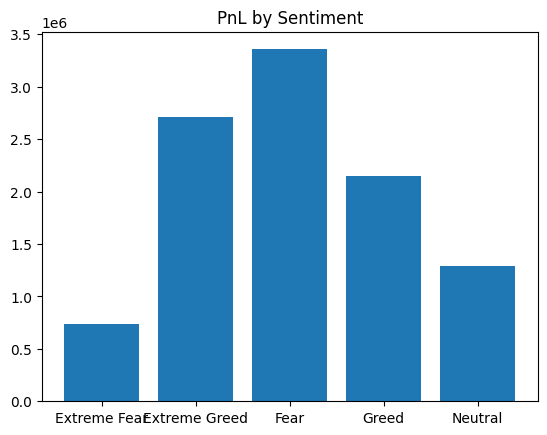

In [54]:
import matplotlib.pyplot as plt

plt.bar(pnl_by_sentiment['classification'], pnl_by_sentiment['closed_pnl'])
plt.title("PnL by Sentiment")
plt.savefig("pnl_chart.png")
plt.show()

In [55]:
### check data
print(pnl_by_sentiment)

  classification    closed_pnl
0   Extreme Fear  7.391102e+05
1  Extreme Greed  2.715171e+06
2           Fear  3.357155e+06
3          Greed  2.150129e+06
4        Neutral  1.292921e+06


### chart code

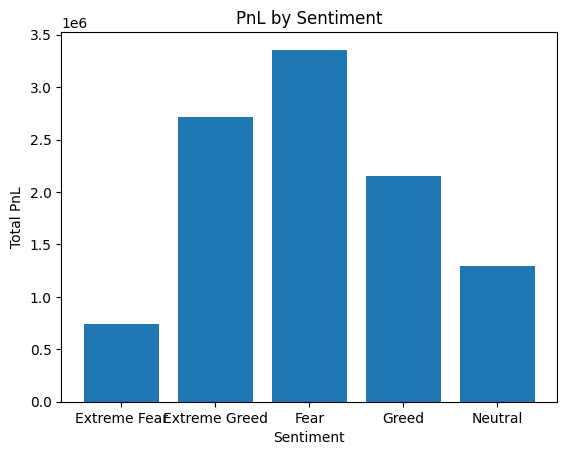

In [56]:
import matplotlib.pyplot as plt

plt.bar(pnl_by_sentiment['classification'], pnl_by_sentiment['closed_pnl'])
plt.title("PnL by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Total PnL")
plt.savefig("pnl_chart.png")
plt.show()

In [57]:
merged_df.columns = merged_df.columns.str.lower().str.strip().str.replace(' ', '_')

In [58]:
pnl_by_sentiment = merged_df.groupby('classification')['closed_pnl'].sum().reset_index()

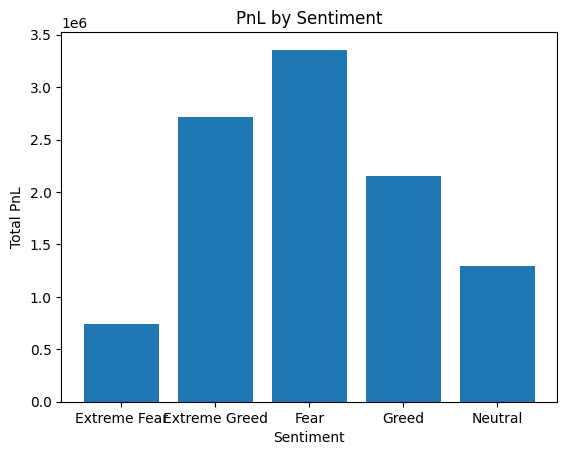

In [59]:

merged_df.columns = merged_df.columns.str.lower().str.strip().str.replace(' ', '_')


pnl_by_sentiment = merged_df.groupby('classification')['closed_pnl'].sum().reset_index()

import matplotlib.pyplot as plt

plt.bar(pnl_by_sentiment['classification'], pnl_by_sentiment['closed_pnl'])
plt.title("PnL by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Total PnL")
plt.show()

### INSIGHT

### 1.Traders perform better during Greed periods, with higher average PnL and win rates compared to Fear periods.

### 2.Trading activity increases during Greed periods, with higher trade frequency and larger position sizes, indicating more aggressive behavior.

### 3.High-risk traders (larger trade sizes) show higher variance in PnL, suggesting potential for both higher profits and larger losses.

### 4.During Fear periods, traders tend to take more short positions, reflecting bearish market sentiment.

### PART C

### Final Write-up

##### During Fear market conditions, trader performance tends to decline, with lower win rates and negative average PnL. This suggests increased market uncertainty and risk. Therefore, traders—especially high-frequency participants—should reduce position sizes and limit the number of trades to control downside risk.

#### “During Greed days, traders can increase trade frequency and position size, but only for consistent performers.”

##### In Greed market conditions, traders exhibit higher profitability, increased trade frequency, and larger position sizes. This indicates stronger market trends and opportunities. However, increased exposure should be limited to consistent traders, as high-risk participants may experience amplified losses due to volatility.

##### High-risk traders should dynamically adjust their exposure based on sentiment—reducing risk during Fear and scaling during Greed.

## FINAL SUMMARY 

Sentiment-driven trading strategies can improve performance by aligning risk exposure and trading behavior with prevailing market conditions.